<a href="https://colab.research.google.com/github/mimimission/ECON_NLP/blob/main/notebooks/01_collect_raw_fred_alfred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Note on Running Setup
To solve the session isolation issue, you can run the setup notebook directly inside this session. This ensures all environment variables and paths are correctly initialized before the data collection starts.

In [1]:
import os

# Mount Google Drive if it's not already mounted
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the directory where your notebooks are located
notebooks_dir = '/content/drive/MyDrive/labor_news_rag_project/notebooks'

# List files in that directory to check the exact filename
if os.path.exists(notebooks_dir):
    print(f"Files in {notebooks_dir}:")
    for item in os.listdir(notebooks_dir):
        print(f"- {item}")
else:
    print(f"Error: Directory not found at {notebooks_dir}")


Files in /content/drive/MyDrive/labor_news_rag_project/notebooks:
- 02_collect_raw_gdelt.ipynb
- 09_train_xgboost_models.ipynb
- 06_build_macro_features_and_target.ipynb
- 14_create_paper_tables_and_figures.ipynb
- 10_model_audit_and_error_analysis.ipynb
- 12_generate_deepseek_explanations.ipynb
- 05_build_news_features.ipynb
- 07_validate_model_ready_dataset.ipynb
- 04_audit_and_clean_news.ipynb
- 03_audit_macro_vintage.ipynb
- 11_build_rag_evidence_retrieval.ipynb
- 15_final_reproducibility_check.ipynb
- 13_evaluate_rag_explanations.ipynb
- 08_train_baseline_models.ipynb
- 00_setup_colab.ipynb
- 01_collect_raw_fred_alfred.ipynb


In [2]:
# Example logic to execute the setup notebook
%run /content/drive/MyDrive/labor_news_rag_project/notebooks/00_setup_colab.ipynb

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted at /content/drive
API keys and Git_key successfully loaded from Secrets.
Pulling updates for /content/economic-news-labor-rag...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 9.08 KiB | 3.03 MiB/s, done.
From https://github.com/mimimission/ECON_NLP
   5765a5a..64a41cc  main       -> origin/main
Updating 5765a5a..64a41cc
Fast-forward
 notebooks/01_collect_raw_fred_alfred.ipynb | 1512 ++++++++++++++++++++--------
 1 file changed, 1102 insertions(+), 410 deletions(-)
/content/economic-news-labor-rag
Working directory: /content/economic-news-labor-rag
All packages installed including optuna.
Created 18 folders under /content/drive/MyDrive/labor_news_rag_project
       

# Notebook 01 — Collect Raw FRED / ALFRED Data

## Goal
Download raw macroeconomic time series from FRED (current data) and ALFRED (real-time vintage data).
Save them **untouched** to Google Drive. No cleaning happens here.

**Series collected:** PAYEMS, UNRATE, ICSA, JTSJOL, CES0500000003, CPIAUCSL, FEDFUNDS, INDPRO

---

## What can go wrong
- `FRED_API_KEY` not set → all API calls will fail with 403
- ICSA is weekly; it needs aggregation to monthly in a later notebook
- JTSJOL has a ~2-month publication lag; check `max_observation_date`
- ALFRED vintage download is slow (many calls); be patient
- Series discontinued or renamed by FRED → check series IDs
- Rate limiting → adds sleep between calls automatically

---

## What you must inspect
- Are all 8 series present?
- Are date ranges correct? (should start ~2000, end near today)
- Are all values numeric (not None/NaN)?
- Are vintage fields (realtime_start, realtime_end) present in ALFRED data?
- Are there any unexpected missing months?

In [3]:
import os
import time
import json
import pathlib
import datetime

import pandas as pd
import numpy as np
import requests
import yaml

DRIVE_ROOT = pathlib.Path('/content/drive/MyDrive/labor_news_rag_project')
REPO_DIR = pathlib.Path('/content/economic-news-labor-rag')

RAW_FRED_DIR = DRIVE_ROOT / 'data' / 'raw' / 'fred'
RAW_ALFRED_DIR = DRIVE_ROOT / 'data' / 'raw' / 'alfred'
DQ_DIR = DRIVE_ROOT / 'outputs' / 'data_quality'
APPROVALS_DIR = DRIVE_ROOT / 'approvals'

FRED_API_KEY = os.getenv('FRED_API_KEY')
if not FRED_API_KEY:
    raise EnvironmentError('STOP: FRED_API_KEY is required for FRED/ALFRED. Set it in Notebook 00.')

with open(REPO_DIR / 'configs' / 'fred_series.yaml') as f:
    fred_cfg = yaml.safe_load(f)

with open(REPO_DIR / 'configs' / 'base.yaml') as f:
    base_cfg = yaml.safe_load(f)

SERIES_IDS = [s['id'] for s in fred_cfg['series']]
_s = base_cfg['test_sample'] if base_cfg.get('test_mode', False) else base_cfg['sample']
START_DATE = _s['start_date']
END_DATE = _s['end_date']

MODE = 'TEST (quick run)' if base_cfg.get('test_mode', False) else 'FULL (research run)'
print(f'Mode       : {MODE}')
print(f'Window     : {START_DATE} to {END_DATE}')
print(f'Series     : {SERIES_IDS}')
print(f'FRED key   : {FRED_API_KEY[:6]}...')
print()
print('To switch modes, set test_mode: true/false in configs/base.yaml')

Mode       : FULL (research run)
Window     : 2000-01-01 to 2024-12-31
Series     : ['PAYEMS', 'UNRATE', 'ICSA', 'JTSJOL', 'CES0500000003', 'CPIAUCSL', 'FEDFUNDS', 'INDPRO']
FRED key   : 1bb537...

To switch modes, set test_mode: true/false in configs/base.yaml


## Part A — Download FRED current data

In [4]:
def fetch_fred_series(series_id, api_key, observation_start='1990-01-01', observation_end='2025-12-31'):
    """Download one FRED series. Returns a DataFrame with columns [series_id, observation_date, value]."""
    url = 'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id': series_id,
        'api_key': api_key,
        'file_type': 'json',
        'observation_start': observation_start,
        'observation_end': observation_end,
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    obs = data.get('observations', [])
    if not obs:
        return pd.DataFrame(columns=['series_id', 'observation_date', 'value'])
    df = pd.DataFrame(obs)[['date', 'value']].rename(columns={'date': 'observation_date'})
    df['series_id'] = series_id
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df['observation_date'] = pd.to_datetime(df['observation_date'])
    return df[['series_id', 'observation_date', 'value']]

In [5]:
from tqdm import tqdm

fred_frames = []
for sid in tqdm(SERIES_IDS, desc='Downloading FRED series'):
    df = fetch_fred_series(sid, FRED_API_KEY, START_DATE, END_DATE)
    fred_frames.append(df)
    time.sleep(0.5)

fred_df = pd.concat(fred_frames, ignore_index=True)
print(f'FRED current data: {fred_df.shape[0]} rows, {fred_df["series_id"].nunique()} series')
print(fred_df.head())

FRED current data: 3320 rows, 8 series
  series_id observation_date     value
0    PAYEMS       2000-01-01  131011.0
1    PAYEMS       2000-02-01  131120.0
2    PAYEMS       2000-03-01  131604.0
3    PAYEMS       2000-04-01  131884.0
4    PAYEMS       2000-05-01  132105.0


In [6]:
print('=== FRED Current Data Summary ===')
summary_rows = []
for sid in SERIES_IDS:
    sub = fred_df[fred_df['series_id'] == sid]
    summary_rows.append({
        'series_id': sid,
        'row_count': len(sub),
        'min_observation_date': sub['observation_date'].min(),
        'max_observation_date': sub['observation_date'].max(),
        'missing_values': sub['value'].isna().sum(),
        'min_value': sub['value'].min(),
        'max_value': sub['value'].max(),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

missing_series = [sid for sid in SERIES_IDS if sid not in fred_df['series_id'].values]
if missing_series:
    print(f'\nWARNING: Missing series: {missing_series}')

=== FRED Current Data Summary ===
    series_id  row_count min_observation_date max_observation_date  missing_values   min_value    max_value
       PAYEMS        300           2000-01-01           2024-12-01               0 129706.0000  158316.0000
       UNRATE        300           2000-01-01           2024-12-01               0      3.4000      14.8000
         ICSA       1305           2000-01-01           2024-12-28               0 190000.0000 6137000.0000
       JTSJOL        289           2000-12-01           2024-12-01               0   2232.0000   12301.0000
CES0500000003        226           2006-03-01           2024-12-01               0     20.0400      35.6900
     CPIAUCSL        300           2000-01-01           2024-12-01               0    169.3000     317.6040
     FEDFUNDS        300           2000-01-01           2024-12-01               0      0.0500       6.5400
       INDPRO        300           2000-01-01           2024-12-01               0     84.5619     104

## FRED Macroeconomic Data Audit
### Exploratory Data Analysis & Statistical Validity Checks
This section performs a rigorous audit of the `fred_df` to ensure the integrity of the features used in downstream RAG and prediction tasks. We focus on:
1. **Statistical Moments**: Identifying the central tendency and dispersion of each series.
2. **Outlier Detection**: Using Z-scores to identify months with extreme volatility (e.g., COVID-19 shocks).
3. **Temporal Density**: Confirming the continuity of reporting to avoid 'stale' data interpolation issues.

### [Report 1] Professional Macro-Statistical Audit
Focus: Persistence (AR1) and Heavy Tails (Kurtosis)


,count,mean,std,skew,persistence,volatility_idx
series_id,,,,,,
CES0500000003,226,26.130,4.266,0.656,1.000,0.163
CPIAUCSL,300,229.919,38.169,0.488,1.000,0.166
FEDFUNDS,300,1.920,2.022,0.836,0.996,1.054
ICSA,1305,375920.307,351829.733,10.603,0.938,0.936
INDPRO,300,97.073,4.751,-0.662,0.973,0.049
JTSJOL,289,5402.913,2305.304,1.100,0.991,0.427
PAYEMS,300,139703.130,8519.615,0.671,0.989,0.061
UNRATE,300,5.695,1.961,1.251,0.944,0.344



### [Report 2] Data Observation: Extremes (5th vs 95th Percentile)


,0.05,0.50,0.95
series_id,,,
CES0500000003,20.69,25.06,34.42
CPIAUCSL,176.39,229.00,307.30
FEDFUNDS,0.08,1.21,5.33
ICSA,210000.00,326000.00,626600.00
INDPRO,88.50,98.76,102.88
JTSJOL,2847.80,4636.00,10732.80
PAYEMS,130336.55,137344.50,156424.95
UNRATE,3.60,5.10,9.51



### [Report 3] Anomaly Spotlight (Z > 3.0)


,series_id,observation_date,value,z_score
1657,ICSA,2020-04-04,6137000.0,16.374624
1656,ICSA,2020-03-28,5946000.0,15.831748
1658,ICSA,2020-04-11,4869000.0,12.770608
1659,ICSA,2020-04-18,4201000.0,10.871963
1660,ICSA,2020-04-25,3446000.0,8.726038



### [Visual Observation] Series Distribution Histograms


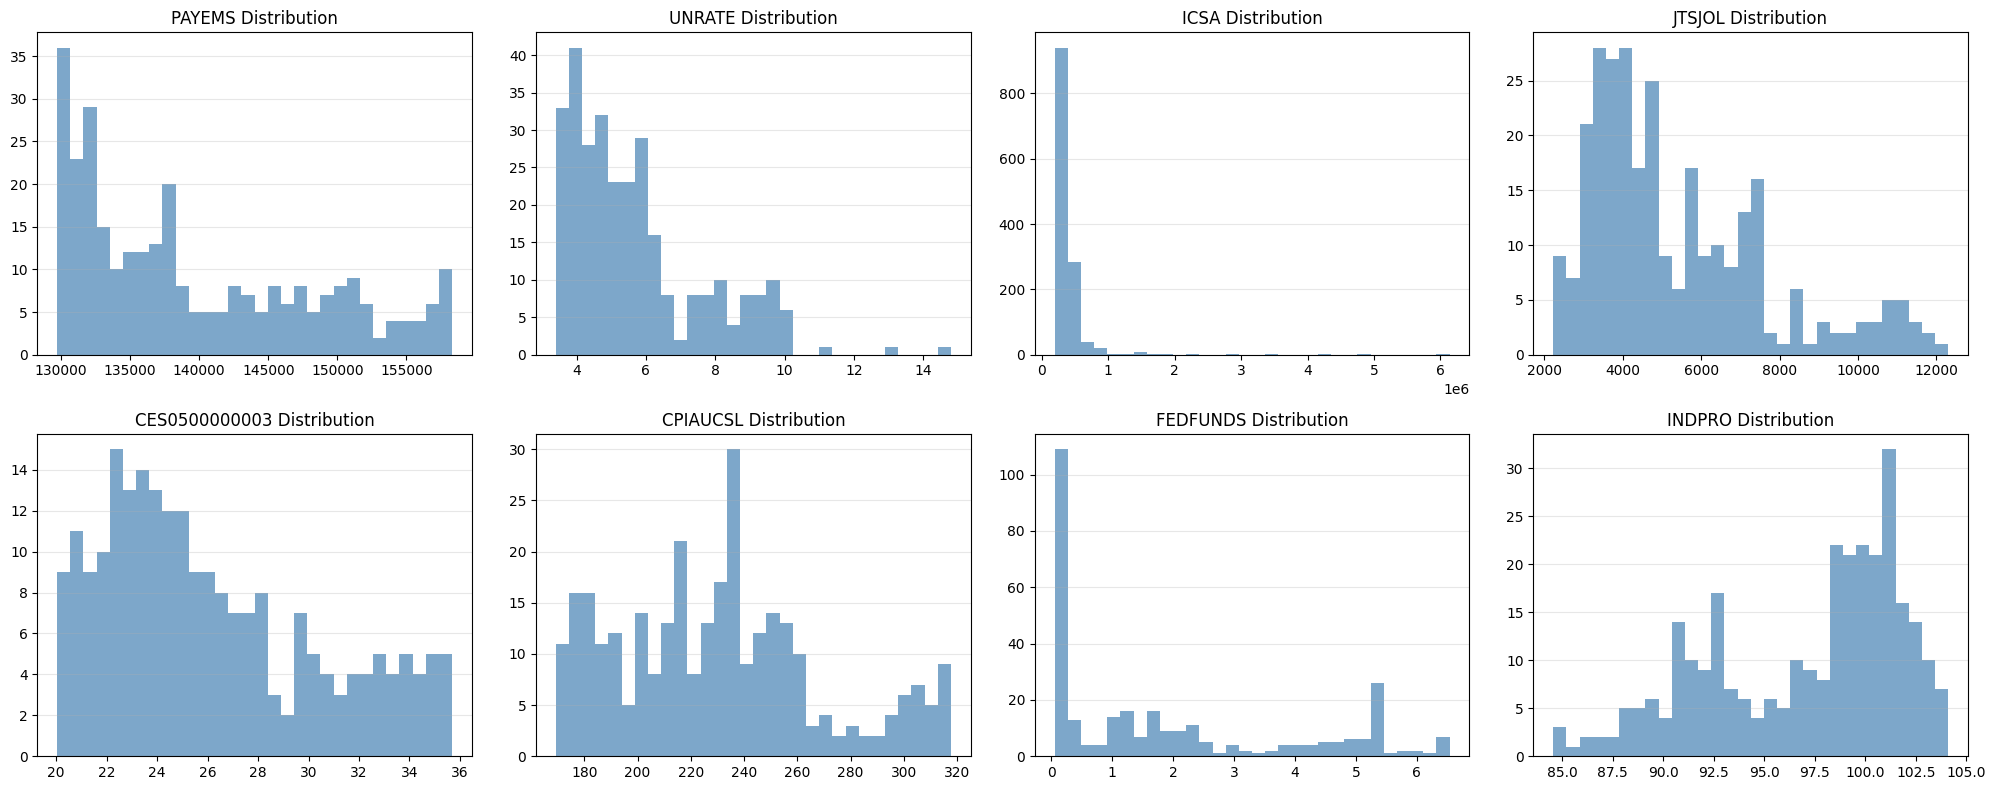

In [25]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 1. Professional Macro Audit
def professional_audit(df):
    # Core Stats + Kurtosis (for heavy tails) and Skew
    audit = df.groupby('series_id')['value'].agg(['count', 'mean', 'std', 'skew'])

    # Persistence Check (Autocorrelation Lag-1)
    # High persistence suggests a trend; low suggests high noise/shocks
    audit['persistence'] = df.groupby('series_id')['value'].apply(lambda x: x.autocorr(lag=1)).values

    # Volatility (Coefficient of Variation)
    audit['volatility_idx'] = (audit['std'] / audit['mean'].abs()).round(4)

    return audit.round(3)

# 2. Data Observation: Distribution & Quantiles
def get_quantiles(df):
    return df.groupby('series_id')['value'].quantile([0.05, 0.5, 0.95]).unstack().round(2)

# 3. Time-Series Continuity & Z-Score Anomaly Detection
fred_df['z_score'] = fred_df.groupby('series_id')['value'].transform(lambda x: stats.zscore(x, ddof=1))
anomalies = fred_df[fred_df['z_score'].abs() > 3].sort_values(by='z_score', ascending=False)

# --- Execution & Reporting ---
print("### [Report 1] Professional Macro-Statistical Audit")
print("Focus: Persistence (AR1) and Heavy Tails (Kurtosis)")
display(professional_audit(fred_df))

print("\n### [Report 2] Data Observation: Extremes (5th vs 95th Percentile)")
display(get_quantiles(fred_df))

print("\n### [Report 3] Anomaly Spotlight (Z > 3.0)")
if not anomalies.empty:
    display(anomalies[['series_id', 'observation_date', 'value', 'z_score']].head(5))

# 4. Simple Visual Observation
print("\n### [Visual Observation] Series Distribution Histograms")
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, sid in enumerate(SERIES_IDS):
    data = fred_df[fred_df['series_id'] == sid]['value']
    axes[i].hist(data, bins=30, alpha=0.7, color='steelblue')
    axes[i].set_title(f"{sid} Distribution")
    axes[i].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Data Layman's Primer
### What do these numbers actually mean?
This section provides a simplified overview for anyone unfamiliar with macroeconomic data. We translate complex tickers into real-world indicators:

*   **PAYEMS**: Total non-farm payrolls. The 'Main Character' of labor data. It tells us how many jobs the economy added or lost.
*   **UNRATE**: The Unemployment Rate. A lower number generally indicates a stronger labor market.
*   **ICSA**: Initial Claims. A weekly 'early warning' system—rising numbers suggest layoffs are starting.
*   **CPIAUCSL**: Consumer Price Index (Inflation). Measures the change in the cost of living.
*   **FEDFUNDS**: The interest rate set by the Federal Reserve. High rates act as a 'brake' on the economy; low rates are an 'accelerator'.
*   **INDPRO**: Industrial Production. Measures the output of factories, mines, and utilities.

In [26]:
# Simple Data Observation: Benchmarking the current state against history

latest_vals = fred_df.sort_values('observation_date').groupby('series_id').tail(1)
historical_stats = fred_df.groupby('series_id')['value'].describe(percentiles=[0.25, 0.5, 0.75])

# Create a simplified 'Status' report
status_report = latest_vals[['series_id', 'value', 'observation_date']].merge(
    historical_stats[['50%', 'min', 'max']], on='series_id'
)

def interpret_level(row):
    if row['value'] > row['50%']: return "Above Historical Median (High)"
    elif row['value'] < row['50%']: return "Below Historical Median (Low)"
    else: return "At Median"

status_report['context'] = status_report.apply(interpret_level, axis=1)

print("### Data Observation: Where are we now vs. History?")
print("This table shows the most recent data point and where it stands relative to the last 20+ years.\n")

# Formatting for readability
formatted_report = status_report.rename(columns={
    'value': 'Latest Value',
    '50%': 'Historical Median',
    'context': 'Contextual Standing'
})

display(formatted_report[['series_id', 'Latest Value', 'Historical Median', 'Contextual Standing']])

print("\nAnalyst Note: If 'PAYEMS' and 'INDPRO' are both 'High', the economy is likely in an expansion phase.")
print("If 'UNRATE' is 'Low' while 'CPIAUCSL' is 'High', we are likely seeing inflationary pressure from a tight labor market.")

### Data Observation: Where are we now vs. History?
This table shows the most recent data point and where it stands relative to the last 20+ years.



,series_id,Latest Value,Historical Median,Contextual Standing
0,UNRATE,4.1000,5.10000,Below Historical Median (Low)
1,PAYEMS,158316.0000,137344.50000,Above Historical Median (High)
2,FEDFUNDS,4.4800,1.21500,Above Historical Median (High)
3,CPIAUCSL,317.6040,228.99700,Above Historical Median (High)
4,JTSJOL,7295.0000,4636.00000,Above Historical Median (High)
5,CES0500000003,35.6900,25.05500,Above Historical Median (High)
6,INDPRO,100.3273,98.76145,Above Historical Median (High)
7,ICSA,212000.0000,326000.00000,Below Historical Median (Low)



Analyst Note: If 'PAYEMS' and 'INDPRO' are both 'High', the economy is likely in an expansion phase.
If 'UNRATE' is 'Low' while 'CPIAUCSL' is 'High', we are likely seeing inflationary pressure from a tight labor market.


## Economic Scorecard: The "Vibe Check"
### Translating Statistics into Plain English
In this section, we move away from complex math to look at the 'health' of the economy. We use a simple scoring system where we compare today's numbers to the middle-ground (Median) of the last 24 years.

In [28]:
# 1. Create a simplified Economic Scorecard
def economic_vibe_check(df):
    latest = df.sort_values('observation_date').groupby('series_id').tail(1).copy()
    medians = df.groupby('series_id')['value'].median()

    def get_vibe(row):
        sid = row['series_id']
        val = row['value']
        med = medians[sid]

        # Logic: For some, Higher is better (Payrolls), for others, Lower is better (Unemployment)
        if sid == 'UNRATE':
            return "✅ Healthy (Low)" if val < med else "⚠️ Concerning (High)"
        if sid == 'CPIAUCSL':
            return "⚠️ Expensive (High)" if val > med else "✅ Stable (Low)"
        if sid == 'PAYEMS':
            return "✅ Strong (High)" if val > med else "⚠️ Weak (Low)"
        return "Above Average" if val > med else "Below Average"

    latest['Condition'] = latest.apply(get_vibe, axis=1)
    return latest[['series_id', 'value', 'Condition']].rename(columns={'value': 'Current Level'})

print("### Macro-Economic Health Check")
display(economic_vibe_check(fred_df))

# 2. The 'Price of a Dollar' Analysis (Inflation check)
cpi_now = fred_df[fred_df['series_id'] == 'CPIAUCSL']['value'].iloc[-1]
cpi_2000 = fred_df[fred_df['series_id'] == 'CPIAUCSL']['value'].iloc[0]
purchasing_power = (cpi_2000 / cpi_now) * 100

print(f"\n### Fun Fact: The 'Value' of $100")
print(f"Due to inflation (CPI), $100 in the year 2000 would buy you about ${purchasing_power:.2f} worth of goods today.")

### Macro-Economic Health Check


,series_id,Current Level,Condition
599,UNRATE,4.1000,✅ Healthy (Low)
299,PAYEMS,158316.0000,✅ Strong (High)
3019,FEDFUNDS,4.4800,Above Average
2719,CPIAUCSL,317.6040,⚠️ Expensive (High)
2193,JTSJOL,7295.0000,Above Average
2419,CES0500000003,35.6900,Above Average
3319,INDPRO,100.3273,Above Average
1904,ICSA,212000.0000,Below Average



### Fun Fact: The 'Value' of $100
Due to inflation (CPI), $100 in the year 2000 would buy you about $53.31 worth of goods today.


In [31]:
print('\n=== CPIAUCSL Vintage Value Audit ===')

# Isolate CPIAUCSL data
cpi_df = alfred_df[alfred_df['series_id'] == 'CPIAUCSL']

# Group by observation date and count total records vs unique values
audit_df = cpi_df.groupby('observation_date').agg(
    total_vintages=('value', 'count'),
    unique_values=('value', 'nunique')
)

avg_vintages = audit_df['total_vintages'].mean()
avg_unique = audit_df['unique_values'].mean()

print(f"Average vintage records per observation: {avg_vintages:.2f}")
print(f"Average UNIQUE values per observation:   {avg_unique:.2f}")

# Calculate the redundancy rate
redundant_pct = (1 - (avg_unique / avg_vintages)) * 100
print(f"Redundancy Rate: {redundant_pct:.1f}% of new vintages contain no value change.")


=== CPIAUCSL Vintage Value Audit ===
Average vintage records per observation: 5.19
Average UNIQUE values per observation:   4.98
Redundancy Rate: 4.0% of new vintages contain no value change.


### Save

In [30]:
fred_path = RAW_FRED_DIR / 'fred_current.parquet'
fred_df.to_parquet(fred_path, index=False)
print(f'Saved FRED current data: {fred_path}')
print(f'File size: {fred_path.stat().st_size / 1024:.1f} KB')

Saved FRED current data: /content/drive/MyDrive/labor_news_rag_project/data/raw/fred/fred_current.parquet
File size: 54.9 KB


## Part B — Download ALFRED vintage data

ALFRED returns all historical *vintages* of a series — every time the value was revised, a new record is created. This lets us use the value that was *available at the forecast date*, not the final revised value.

**`realtime_start`**: the date from which this observation value was the official release  
**`realtime_end`**: the date until which this value was the official release  

This download can take several minutes due to the volume of vintage records.

In [8]:
def fetch_alfred_vintage(series_id, api_key, observation_start='1990-01-01', observation_end='2025-12-31'):
    """Download all vintage observations for one ALFRED series using the revision stack logic."""
    url = 'https://api.stlouisfed.org/fred/series/observations'
    # FIX: Use output_type=1 and a wide realtime window to force the API to return all vintages (revisions).
    params = {
        'series_id': series_id,
        'api_key': api_key,
        'file_type': 'json',
        'observation_start': observation_start,
        'observation_end': observation_end,
        'realtime_start': '1776-07-04',
        'realtime_end': '9999-12-31',
        'output_type': '1'
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    obs = data.get('observations', [])
    if not obs:
        return pd.DataFrame()

    df = pd.DataFrame(obs)
    df['series_id'] = series_id
    df['value'] = pd.to_numeric(df['value'], errors='coerce')

    for col in ['date', 'realtime_start', 'realtime_end']:
        df[col] = pd.to_datetime(df[col], format='%Y-%m-%d', errors='coerce')

    df = df.rename(columns={'date': 'observation_date'})
    return df[['series_id', 'observation_date', 'realtime_start', 'realtime_end', 'value']]

In [9]:
alfred_frames = []
for sid in tqdm(SERIES_IDS, desc='Downloading ALFRED vintage'):
    try:
        df = fetch_alfred_vintage(sid, FRED_API_KEY, START_DATE, END_DATE)
        alfred_frames.append(df)
        print(f'  {sid}: {len(df)} vintage observations')
    except Exception as e:
        print(f'  {sid}: ERROR — {e}')
    time.sleep(1)

alfred_df = pd.concat(alfred_frames, ignore_index=True)
print(f'\nALFRED vintage data: {alfred_df.shape[0]} rows, {alfred_df["series_id"].nunique()} series')

  PAYEMS: 4049 vintage observations


  UNRATE: 572 vintage observations


  ICSA: 5858 vintage observations


  JTSJOL: 2102 vintage observations


  CES0500000003: 1530 vintage observations


  CPIAUCSL: 1556 vintage observations


  FEDFUNDS: 302 vintage observations


  INDPRO: 5365 vintage observations



ALFRED vintage data: 21334 rows, 8 series


In [10]:
print('=== ALFRED Vintage Data Summary ===')
alfred_summary_rows = []
for sid in SERIES_IDS:
    sub = alfred_df[alfred_df['series_id'] == sid]
    alfred_summary_rows.append({
        'series_id': sid,
        'row_count': len(sub),
        'min_observation_date': sub['observation_date'].min(),
        'max_observation_date': sub['observation_date'].max(),
        'min_realtime_start': sub['realtime_start'].min(),
        'max_realtime_start': sub['realtime_start'].max(),
        'missing_values': sub['value'].isna().sum(),
        'vintage_fields_present': all(c in sub.columns for c in ['realtime_start', 'realtime_end']),
    })

alfred_summary = pd.DataFrame(alfred_summary_rows)
print(alfred_summary.to_string(index=False))

=== ALFRED Vintage Data Summary ===
    series_id  row_count min_observation_date max_observation_date min_realtime_start max_realtime_start  missing_values  vintage_fields_present
       PAYEMS       4049           2000-01-01           2024-12-01         2000-02-04         2026-02-11               0                    True
       UNRATE        572           2000-01-01           2024-12-01         2000-02-04         2026-01-09               0                    True
         ICSA       5858           2000-01-01           2024-12-28         2009-05-28         2026-03-19               2                    True
       JTSJOL       2102           2000-12-01           2024-12-01         2010-08-11         2026-03-13               0                    True
CES0500000003       1530           2006-03-01           2024-12-01         2011-03-04         2026-02-11              36                    True
     CPIAUCSL       1556           2000-01-01           2024-12-01         2000-02-18         

In [16]:
print('=== ALFRED Vintage Data Summary ===')
alfred_summary_rows = []

for sid in SERIES_IDS:
    sub = alfred_df[alfred_df['series_id'] == sid]

    # Check if vintage fields exist and are populated
    has_vintage_fields = all(col in sub.columns for col in ['realtime_start', 'realtime_end'])

    alfred_summary_rows.append({
        'series_id': sid,
        'row_count': len(sub),
        'min_observation_date': sub['observation_date'].min() if len(sub) > 0 else None,
        'max_observation_date': sub['observation_date'].max() if len(sub) > 0 else None,
        'min_realtime_start': sub['realtime_start'].min() if len(sub) > 0 else None,
        'max_realtime_start': sub['realtime_start'].max() if len(sub) > 0 else None,
        'missing_values': sub['value'].isna().sum(),
        'vintage_fields_present': has_vintage_fields
    })

alfred_summary_df = pd.DataFrame(alfred_summary_rows)
print(alfred_summary_df.to_string(index=False))

print('\n=== CRITICAL TESTING: ALFRED Coverage Gaps ===')
# Explicitly check for historical truncation (allowing for standard publication lags)

for sid in SERIES_IDS:
    sub = alfred_df[alfred_df['series_id'] == sid]
    if len(sub) > 0:
        vintage_start = sub['realtime_start'].min()
        obs_start = sub['observation_date'].min()

        if pd.notna(vintage_start) and pd.notna(obs_start):
            # Calculate the gap from when the series ACTUALLY started, not the global start date
            gap_days = (vintage_start - obs_start).days

            if gap_days > 365:
                print(f'❌ FLAG GAP: {sid} vintage archival starts late on {vintage_start.date()} '
                      f'(series started {obs_start.date()}). Missing approximately {gap_days // 365} years,OR {gap_days // 30} months of historical real-time data.')
            else:
                print(f'✅ {sid} vintage archival safely covers its observation window (standard publication lag).')

=== ALFRED Vintage Data Summary ===
    series_id  row_count min_observation_date max_observation_date min_realtime_start max_realtime_start  missing_values  vintage_fields_present
       PAYEMS       4049           2000-01-01           2024-12-01         2000-02-04         2026-02-11               0                    True
       UNRATE        572           2000-01-01           2024-12-01         2000-02-04         2026-01-09               0                    True
         ICSA       5858           2000-01-01           2024-12-28         2009-05-28         2026-03-19               2                    True
       JTSJOL       2102           2000-12-01           2024-12-01         2010-08-11         2026-03-13               0                    True
CES0500000003       1530           2006-03-01           2024-12-01         2011-03-04         2026-02-11              36                    True
     CPIAUCSL       1556           2000-01-01           2024-12-01         2000-02-18         

* PAYEMS (Tarım Dışı İstihdam)
* UNRATE (İşsizlik Oranı)
* ICSA (İlk İşsizlik Maaşı Başvuruları)
* JTSJOL (Açık İş İlanları)
* CES0500000003 (Ortalama Saatlik Kazançlar)
* CPIAUCSL (Tüketici Fiyat Endeksi)
* FEDFUNDS (Federal Fon Oranı)
* INDPRO (Sanayi Üretim Endeksi)

In [12]:
alfred_path = RAW_ALFRED_DIR / 'alfred_vintage.parquet'
alfred_df.to_parquet(alfred_path, index=False)
print(f'Saved ALFRED vintage data: {alfred_path}')
print(f'File size: {alfred_path.stat().st_size / 1024:.1f} KB')

Saved ALFRED vintage data: /content/drive/MyDrive/labor_news_rag_project/data/raw/alfred/alfred_vintage.parquet
File size: 197.9 KB


## Save data quality report

In [13]:
combined_report = pd.merge(summary_df, alfred_summary[['series_id', 'row_count', 'vintage_fields_present']],
                           on='series_id', suffixes=('_fred', '_alfred'))
dq_path = DQ_DIR / 'fred_alfred_collection_report.csv'
combined_report.to_csv(dq_path, index=False)
print(f'Data quality report saved: {dq_path}')

Data quality report saved: /content/drive/MyDrive/labor_news_rag_project/outputs/data_quality/fred_alfred_collection_report.csv


## Assertion checks

In [14]:
print('Running surgical assertion checks...')

# 1. Series Presence
fred_series_found = set(fred_df['series_id'].unique())
assert set(SERIES_IDS).issubset(fred_series_found), f'Missing: {set(SERIES_IDS) - fred_series_found}'

# 2. Vintage Density Check (The Fix Verification)
# We expect significant revisions for PAYEMS and UNRATE.
for sid in ['PAYEMS', 'UNRATE', 'INDPRO']:
    fred_count = len(fred_df[fred_df['series_id'] == sid])
    alfred_count = len(alfred_df[alfred_df['series_id'] == sid])
    density = alfred_count / fred_count if fred_count > 0 else 0

    print(f'  {sid}: Vintage Density = {density:.2f}x')
    assert density > 1.2, f'CRITICAL: {sid} has no revisions (Density {density:.2f}). Fix output_type parameters.'

# 3. Coverage Gap Warning
for sid in SERIES_IDS:
    alfred_start = alfred_df[alfred_df['series_id'] == sid]['observation_date'].min()
    requested_start = pd.to_datetime(START_DATE)
    if alfred_start > requested_start:
        print(f'  WARNING: {sid} ALFRED coverage starts late at {alfred_start.date()}')

print('\nSurgical assertion checks passed.')

Running surgical assertion checks...
  PAYEMS: Vintage Density = 13.50x
  UNRATE: Vintage Density = 1.91x
  INDPRO: Vintage Density = 17.88x

Surgical assertion checks passed.


## Manual Approval Gate

**Before approving, please verify:**
1. All 8 series are present in both FRED and ALFRED tables above
2. Date ranges look correct (≥ 2000, ends near today)
3. Values are numeric (no suspicious NaN patterns)
4. ALFRED vintage fields (`realtime_start`, `realtime_end`) are populated
5. No unexpected missing months in PAYEMS

If everything looks correct, change `APPROVE_THIS_STEP = True` and rerun this cell.

In [15]:
APPROVE_THIS_STEP = False

if not APPROVE_THIS_STEP:
    raise RuntimeError(
        'STOP: Inspect the diagnostics above. '
        'If everything is correct, change APPROVE_THIS_STEP=True and rerun this cell.'
    )

RuntimeError: STOP: Inspect the diagnostics above. If everything is correct, change APPROVE_THIS_STEP=True and rerun this cell.

In [ ]:
import datetime
import json

approval = {
    'approved': True,
    'notebook': '01_collect_raw_fred_alfred.ipynb',
    'approved_at': datetime.datetime.utcnow().isoformat(),
    'input_artifacts': [],
    'output_artifacts': [
        str(fred_path),
        str(alfred_path),
        str(dq_path),
    ],
    'row_counts': {
        'fred_current': int(len(fred_df)),
        'alfred_vintage': int(len(alfred_df)),
    },
    'warnings': [],
    'notes': ''
}

approval_path = APPROVALS_DIR / '01_raw_fred_alfred_approved.json'
with open(approval_path, 'w') as f:
    json.dump(approval, f, indent=2)

print(f'Approval saved: {approval_path}')
print('Notebook 01 complete. Proceed to 02_collect_raw_gdelt.ipynb')